# HLS-CMDS EDA: Metadata Diversity, Acoustic Identity, and Leakage Risk

This notebook is built section-by-section per `PLAN.md`. Every headline number below is computed live from the source data — nothing is hard-coded from the planning documents.

**Primary thesis:** the dataset's metadata describes more independent scenarios than its audio actually contains. Exact byte-level reuse is substantial, crosses metadata contexts, and has a direct measurable consequence for naive downstream evaluation.

**Terminology note (frozen, see `PLAN.md` Section 6):** this notebook never uses the phrase "unique templates" to describe hash-group counts. A shared SHA256 hash proves byte-identity only, not physiological source identity. We use "distinct byte-level audio identities" throughout.

---
## Section 1 — Environment and Reproducibility Bootstrap


In [1]:
import hashlib
import os
import sys
import warnings

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import scipy

warnings.filterwarnings("default")  # surface warnings rather than silencing them

SEED = 42
RAW_DIR = "../data/raw"
CACHE_DIR = "../cache"
OUTPUT_DIR = "../outputs"

rng = np.random.default_rng(SEED)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("soundfile:", sf.__version__)
print("librosa:", librosa.__version__)
print("scipy:", scipy.__version__)

Python: 3.10.11
pandas: 2.2.3
numpy: 1.26.4
soundfile: 0.14.0
librosa: 0.11.0
scipy: 1.15.3


In [2]:
# Dataset fingerprint -- used as the cache-invalidation key throughout (PLAN.md Section 29)
archive_path = os.path.join(RAW_DIR, "HLS-CMDS.zip")
with open(archive_path, "rb") as f:
    ARCHIVE_FINGERPRINT = hashlib.sha256(f.read()).hexdigest()

print("Archive SHA256 fingerprint:", ARCHIVE_FINGERPRINT)

assert os.path.isdir(RAW_DIR), f"RAW_DIR not found: {RAW_DIR}"
assert len(os.listdir(RAW_DIR)) > 0, f"RAW_DIR is empty: {RAW_DIR}"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Environment bootstrap OK.")

Archive SHA256 fingerprint: 2726a714187c5cbbc5ae6b4992fc1995007fb87aecc6ddd2c551d7bf6f5c678d
Environment bootstrap OK.


---
## Section 2 — Archive and File Inventory

**Objective:** produce a clean, complete, junk-free file manifest.
**Why this section exists:** every later hash/audio computation depends on iterating over the correct file set. macOS packaging artifacts (`__MACOSX/`, `.DS_Store`) and bundled `README.txt` files must be explicitly excluded, not accidentally hashed as if they were audio.


In [3]:
import zipfile

def extract_archive(zip_path, dest_dir):
    """Extract a zip archive, explicitly skipping macOS junk (__MACOSX/, .DS_Store)."""
    with zipfile.ZipFile(zip_path) as z:
        for member in z.namelist():
            if member.startswith("__MACOSX/") or os.path.basename(member) == ".DS_Store":
                continue
            z.extract(member, dest_dir)

# Outer archive first
extract_archive(archive_path, RAW_DIR)

# Then the three inner archives (HS.zip, LS.zip, Mix.zip)
for name in ["HS", "LS", "Mix"]:
    inner_zip = os.path.join(RAW_DIR, f"{name}.zip")
    extract_archive(inner_zip, os.path.join(RAW_DIR, f"{name}_extracted"))

print("Extraction complete.")

Extraction complete.


In [4]:
def discover_files(raw_dir):
    """
    Build a clean file manifest: path, role, filename.
    Roles: HS, LS, Mix-H, Mix-L, Mix-M.
    Excludes README.txt and any residual junk explicitly.
    """
    rows = []
    folders = [
        ("HS_extracted/HS", "HS"),
        ("LS_extracted/LS", "LS"),
        ("Mix_extracted/Mix", "Mix"),
    ]
    for folder, role_prefix in folders:
        full = os.path.join(raw_dir, folder)
        if not os.path.isdir(full):
            continue
        for f in sorted(os.listdir(full)):
            if f in (".DS_Store", "README.txt"):
                continue
            if not f.endswith(".wav"):
                continue
            if role_prefix == "Mix":
                if f.startswith("H"):
                    role = "Mix-H"
                elif f.startswith("L"):
                    role = "Mix-L"
                elif f.startswith("M"):
                    role = "Mix-M"
                else:
                    role = "Mix-?"
            else:
                role = role_prefix
            rows.append({"path": os.path.join(full, f), "role": role, "filename": f})
    return pd.DataFrame(rows)

manifest = discover_files(RAW_DIR)
print("Total files discovered:", len(manifest))
print(manifest["role"].value_counts())

Total files discovered: 535
role
Mix-H    145
Mix-L    145
Mix-M    145
HS        50
LS        50
Name: count, dtype: int64


In [5]:
# Decision gate (PLAN.md Section 32): halt if counts don't match expected inventory
EXPECTED_COUNTS = {"HS": 50, "LS": 50, "Mix-H": 145, "Mix-L": 145, "Mix-M": 145}
actual_counts = manifest["role"].value_counts().to_dict()

assert len(manifest) == 535, f"Expected 535 total files, got {len(manifest)}"
for role, expected_n in EXPECTED_COUNTS.items():
    actual_n = actual_counts.get(role, 0)
    assert actual_n == expected_n, f"Role '{role}': expected {expected_n}, got {actual_n}"

print("All inventory count validations PASSED (535 total, matching expected per-role breakdown).")

manifest_path = os.path.join(CACHE_DIR, "manifest.csv")
manifest.to_csv(manifest_path, index=False)
print(f"Cached: {manifest_path}")

All inventory count validations PASSED (535 total, matching expected per-role breakdown).
Cached: ../cache\manifest.csv


---
## Section 3 — Metadata Audit and Reconciliation

**Objective:** establish trustworthy label data before any later join relies on it.
**Why this section exists:** as found during planning, `LS.csv`'s ID column uses a different abbreviation scheme than the on-disk filenames for two lung-sound classes. If this isn't caught and fixed here, first, every later section that joins metadata to audio would be silently corrupted for those 15 files.

We deliberately show the break before showing the fix.


In [6]:
hs_csv = pd.read_csv(os.path.join(RAW_DIR, "HS.csv"))
ls_csv = pd.read_csv(os.path.join(RAW_DIR, "LS.csv"))
mix_csv = pd.read_csv(os.path.join(RAW_DIR, "Mix.csv"))

print("=== Basic schema checks ===")
for name, df in [("HS", hs_csv), ("LS", ls_csv), ("Mix", mix_csv)]:
    print(f"{name}.csv: shape={df.shape}, nulls={df.isnull().sum().sum()}, duplicate_rows={df.duplicated().sum()}")

=== Basic schema checks ===
HS.csv: shape=(50, 4), nulls=0, duplicate_rows=0
LS.csv: shape=(50, 4), nulls=0, duplicate_rows=0
Mix.csv: shape=(145, 7), nulls=0, duplicate_rows=0


### 3.1 — Demonstrating the break: LS.csv IDs vs. on-disk filenames

In [7]:
ls_files_on_disk = set(
    f[:-4] for f in os.listdir(os.path.join(RAW_DIR, "LS_extracted", "LS")) if f.endswith(".wav")
)
ls_ids_raw = set(ls_csv["Lung Sound ID"])

orphan_csv_rows = ls_ids_raw - ls_files_on_disk
orphan_files = ls_files_on_disk - ls_ids_raw

print("Orphan CSV IDs (no matching file) BEFORE correction:", len(orphan_csv_rows))
print("Orphan files (no matching CSV ID) BEFORE correction:", len(orphan_files))
print("\nExample orphan CSV IDs:", sorted(orphan_csv_rows)[:5])
print("Example orphan files:   ", sorted(orphan_files)[:5])

Orphan CSV IDs (no matching file) BEFORE correction: 15
Orphan files (no matching CSV ID) BEFORE correction: 15

Example orphan CSV IDs: [' M_W_LMA', 'F_C_LUA', 'F_C_RLA', 'F_G_LLA', 'F_G_LMA']
Example orphan files:    ['F_CC_LLA', 'F_CC_LMA', 'F_CC_LUA', 'F_CC_RLA', 'F_CC_RMA']


In [8]:
# Diagnose exactly which abbreviations are involved
ls_csv["abbrev"] = ls_csv["Lung Sound ID"].str.strip().str.split("_").str[1]
print("Abbreviation used per Lung Sound Type (from CSV IDs):")
print(ls_csv.groupby("Lung Sound Type")["abbrev"].unique())

# Whitespace check
ws_rows = ls_csv[ls_csv["Lung Sound ID"] != ls_csv["Lung Sound ID"].str.strip()]
print("\nRows with leading/trailing whitespace in ID:")
print(ws_rows[["Gender", "Lung Sound Type", "Location", "Lung Sound ID"]])

Abbreviation used per Lung Sound Type (from CSV IDs):
Lung Sound Type
Coarse Crackles     [G]
Fine Crackles       [C]
Normal              [N]
Pleural Rub        [PR]
Rhonchi             [R]
Wheezing            [W]
Name: abbrev, dtype: object

Rows with leading/trailing whitespace in ID:
   Gender Lung Sound Type Location Lung Sound ID
45      M        Wheezing      LMA       M_W_LMA


**Diagnosis:** the CSV encodes `Coarse Crackles` → `G` and `Fine Crackles` → `C`, but the on-disk filenames use `CC` and `FC` respectively — a genuine, two-class abbreviation-scheme mismatch (15 rows), plus one row with a leading-space ID (`" M_W_LMA"`).

### 3.2 — Explicit, visible correction (no silent fixing)


In [9]:
# Explicit correction mapping -- applied visibly, never silently upstream
ABBREV_CORRECTION_MAP = {"G": "CC", "C": "FC"}  # CSV abbrev -> actual on-disk filename abbrev

def csv_id_to_filename_stem(raw_id: str) -> str:
    parts = raw_id.strip().split("_")
    gender, ab, loc = parts[0], parts[1], "_".join(parts[2:])
    ab_fixed = ABBREV_CORRECTION_MAP.get(ab, ab)
    return f"{gender}_{ab_fixed}_{loc}"

ls_csv["fname_stem"] = ls_csv["Lung Sound ID"].apply(csv_id_to_filename_stem)

# Validation: post-correction set-difference must be empty -- this is a hard decision gate.
corrected_ids = set(ls_csv["fname_stem"])
orphan_after = corrected_ids - ls_files_on_disk
orphan_files_after = ls_files_on_disk - corrected_ids

print("Orphan CSV IDs AFTER correction:", len(orphan_after))
print("Orphan files AFTER correction:", len(orphan_files_after))

assert len(orphan_after) == 0 and len(orphan_files_after) == 0, \
    "Correction did not fully resolve the mismatch -- halting per PLAN.md Section 32 decision gate."
print("PASS: post-correction join is fully validated (empty set-difference).")

Orphan CSV IDs AFTER correction: 0
Orphan files AFTER correction: 0
PASS: post-correction join is fully validated (empty set-difference).


### 3.3 — Confirm HS.csv and Mix.csv do not have an analogous mismatch

In [10]:
hs_files_on_disk = set(
    f[:-4] for f in os.listdir(os.path.join(RAW_DIR, "HS_extracted", "HS")) if f.endswith(".wav")
)
hs_ids = set(hs_csv["Heart Sound ID"])
print("HS.csv orphan check -- CSV not on disk:", len(hs_ids - hs_files_on_disk),
      "| files not in CSV:", len(hs_files_on_disk - hs_ids))

mix_files_all = set(
    f[:-4] for f in os.listdir(os.path.join(RAW_DIR, "Mix_extracted", "Mix")) if f.endswith(".wav")
)
mix_h_files = set(f for f in mix_files_all if f.startswith("H"))
mix_l_files = set(f for f in mix_files_all if f.startswith("L"))
mix_m_files = set(f for f in mix_files_all if f.startswith("M"))

mix_h_ids = set(mix_csv["Heart Sound ID"])
mix_l_ids = set(mix_csv["Lung Sound ID"])
mix_m_ids = set(mix_csv["Mixed Sound ID"])

print("Mix-H orphan check -- CSV not on disk:", len(mix_h_ids - mix_h_files),
      "| files not in CSV:", len(mix_h_files - mix_h_ids))
print("Mix-L orphan check -- CSV not on disk:", len(mix_l_ids - mix_l_files),
      "| files not in CSV:", len(mix_l_files - mix_l_ids))
print("Mix-M orphan check -- CSV not on disk:", len(mix_m_ids - mix_m_files),
      "| files not in CSV:", len(mix_m_files - mix_m_ids))

print("\nHS.csv and Mix.csv show no analogous mismatch -- LS.csv's abbreviation bug appears isolated.")

HS.csv orphan check -- CSV not on disk: 0 | files not in CSV: 0
Mix-H orphan check -- CSV not on disk: 0 | files not in CSV: 0
Mix-L orphan check -- CSV not on disk: 0 | files not in CSV: 0
Mix-M orphan check -- CSV not on disk: 0 | files not in CSV: 0

HS.csv and Mix.csv show no analogous mismatch -- LS.csv's abbreviation bug appears isolated.


In [11]:
# Build the issue log (first-class output, not a footnote) -- PLAN.md Section 3/28
issue_log_rows = [
    {
        "issue_type": "abbreviation_scheme_mismatch",
        "scope": "LS.csv",
        "affected_ids": "15 rows (Coarse Crackles, Fine Crackles classes)",
        "evidence": "CSV encodes G=Coarse Crackles, C=Fine Crackles; on-disk filenames use CC, FC respectively",
        "confidence": "High",
        "recommended_handling": "Explicit correction map {'G':'CC','C':'FC'} applied visibly; validated via empty set-difference",
    },
    {
        "issue_type": "whitespace_in_id",
        "scope": "LS.csv row 45",
        "affected_ids": "' M_W_LMA' (leading space)",
        "evidence": "Lung Sound ID != Lung Sound ID.str.strip()",
        "confidence": "High",
        "recommended_handling": "Handled by .strip() in csv_id_to_filename_stem()",
    },
]
issue_log = pd.DataFrame(issue_log_rows)
issue_log_path = os.path.join(CACHE_DIR, "issue_log.csv")
issue_log.to_csv(issue_log_path, index=False)
print(f"Cached: {issue_log_path}")
issue_log

Cached: ../cache\issue_log.csv


,issue_type,scope,affected_ids,evidence,confidence,recommended_handling
0,abbreviation_scheme_mismatch,LS.csv,"15 rows (Coarse Crackles, Fine Crackles classes)","CSV encodes G=Coarse Crackles, C=Fine Crackles...",High,"Explicit correction map {'G':'CC','C':'FC'} ap..."
1,whitespace_in_id,LS.csv row 45,' M_W_LMA' (leading space),Lung Sound ID != Lung Sound ID.str.strip(),High,Handled by .strip() in csv_id_to_filename_stem()


In [12]:
# Cache the corrected LS lookup for reuse in later sections
ls_lookup_path = os.path.join(CACHE_DIR, "ls_lookup_corrected.csv")
ls_csv.to_csv(ls_lookup_path, index=False)
print(f"Cached: {ls_lookup_path}")

Cached: ../cache\ls_lookup_corrected.csv


---
## Section 4 — Audio Technical Integrity

**Objective:** confirm the audio itself is readable, uniform, and free of gross defects, and rigorously characterize amplitude/clipping.
**Why this section exists:** later sections (hashing, feature extraction, the Mix experiment) assume every file loads correctly and behaves as expected; this is where that assumption is tested, not assumed.


In [13]:
def audio_full_scan(manifest_df, near_full_threshold=0.999):
    """
    Load every file once; compute technical stats + rigorous full-scale/plateau characterization.
    Definition: exact full-scale sample count + max consecutive run length at/above
    `near_full_threshold` (a multi-sample plateau, not just a single high peak, is
    suggestive of possible digital clipping -- though a legitimate high-amplitude
    transient or quantization/format effects could also produce a similar short event).
    """
    rows = []
    load_failures = []
    for _, r in manifest_df.iterrows():
        try:
            info = sf.info(r["path"])
            data, sr = sf.read(r["path"])
        except Exception as e:
            load_failures.append({"path": r["path"], "error": str(e)})
            continue
        d = data.astype(np.float64)
        near_full = np.abs(d) >= near_full_threshold
        max_run, cur = 0, 0
        for v in near_full:
            if v:
                cur += 1
                max_run = max(max_run, cur)
            else:
                cur = 0
        rows.append({
            "role": r["role"], "filename": r["filename"],
            "sr": info.samplerate, "channels": info.channels, "subtype": info.subtype,
            "duration": info.duration, "frames": info.frames,
            "min": d.min(), "max": d.max(), "max_abs": np.max(np.abs(d)) if len(d) else 0.0,
            "rms": np.sqrt(np.mean(d ** 2)), "dc_offset": d.mean(),
            "nan": bool(np.isnan(d).any()), "inf": bool(np.isinf(d).any()),
            "near_silent": bool(np.sqrt(np.mean(d ** 2)) < 1e-4),
            "n_samples_near_fullscale": int(near_full.sum()),
            "max_consecutive_run_near_fullscale": max_run,
        })
    return pd.DataFrame(rows), load_failures

audio_manifest, load_failures = audio_full_scan(manifest)

print("Total files processed:", len(audio_manifest), "| load failures:", len(load_failures))
assert len(load_failures) == 0, f"Unexpected load failures: {load_failures}"
assert not audio_manifest["nan"].any(), "NaN found in audio data"
assert not audio_manifest["inf"].any(), "Inf found in audio data"
print("PASS: all 535 files loaded cleanly, zero NaN/Inf.")

Total files processed: 535 | load failures: 0
PASS: all 535 files loaded cleanly, zero NaN/Inf.


In [14]:
print("Format uniformity check:")
print("  Sample rates:", audio_manifest["sr"].unique())
print("  Channels:", audio_manifest["channels"].unique())
print("  Subtypes:", audio_manifest["subtype"].unique())
print("  Duration range:", audio_manifest["duration"].min(), "-", audio_manifest["duration"].max())
print("  Near-silent files (RMS < 1e-4):", audio_manifest["near_silent"].sum())

print("\nThis total uniformity (4000Hz/mono/16-bit/15.00s across all 535 files) is itself")
print("a synthetic-data fingerprint, revisited in the final synthesis -- not a quality defect.")

Format uniformity check:
  Sample rates: [4000]
  Channels: [1]
  Subtypes: ['PCM_16']
  Duration range: 15.0 - 15.0
  Near-silent files (RMS < 1e-4): 0

This total uniformity (4000Hz/mono/16-bit/15.00s across all 535 files) is itself
a synthetic-data fingerprint, revisited in the final synthesis -- not a quality defect.


**Note on a sample-rate discrepancy with external listings (added in QA patch):** some external HLS-CMDS dataset listings (e.g. IEEE DataPort's public description) state a sampling rate of 22,050 Hz, which does not match the `4000 Hz` measured directly above. We do not know whether this reflects a different dataset release, a resampled/republished copy, or a listing error -- we have not found conclusive evidence to resolve it either way, and we are not speculating further. **The attached dataset copy used in this analysis is empirically verified at 4 kHz across every inspected WAV file (535/535, confirmed above), and all frequency-domain computations in this notebook use that measured property of the actual files analyzed here** -- not the externally listed figure.


### 4.1 — Rigorous clipping characterization (Mix-M files)

We characterize full-scale amplitude events rigorously rather than by eyeballing peak amplitude: a multi-sample plateau (a run of ≥2 consecutive samples at/near full-scale) is suggestive of possible digital clipping, distinct from a single loud transient sample -- though it is not on its own definitive proof of clipping, since a legitimate high-amplitude transient or quantization/format effects could produce a similar short ceiling event. We report both a looser threshold (`|amplitude| >= 0.999`) and the strict exact int16 ceiling (`32767/32768`), since the two can disagree at the margin — as they do here.


In [15]:
mix_m = audio_manifest[audio_manifest["role"] == "Mix-M"].copy()

touches_fullscale_loose = (mix_m["n_samples_near_fullscale"] > 0).sum()
plateau_loose = (mix_m["max_consecutive_run_near_fullscale"] >= 2).sum()
print(f"Mix-M files with >=1 sample at |amplitude|>=0.999 (loose threshold): {touches_fullscale_loose}/145")
print(f"Mix-M files with a run>=2 at that loose threshold: {plateau_loose}/145")

# Cross-check against the exact int16 ceiling specifically
EXACT_CEILING = 32767 / 32768

def max_run_at_threshold(path, threshold):
    d, sr = sf.read(path)
    d = d.astype(np.float64)
    near = np.abs(d) >= threshold
    max_run, cur = 0, 0
    for v in near:
        if v:
            cur += 1
            max_run = max(max_run, cur)
        else:
            cur = 0
    return max_run

strict_runs = mix_m["filename"].apply(
    lambda f: max_run_at_threshold(os.path.join(RAW_DIR, "Mix_extracted", "Mix", f), EXACT_CEILING - 1e-9)
)
plateau_strict = (strict_runs >= 2).sum()
print(f"Mix-M files with a run>=2 at the EXACT int16 ceiling: {plateau_strict}/145")

plateau_files = mix_m[mix_m["max_consecutive_run_near_fullscale"] >= 2][["filename", "max_abs", "n_samples_near_fullscale"]]
print("\nFiles flagged under the loose threshold:")
print(plateau_files)

Mix-M files with >=1 sample at |amplitude|>=0.999 (loose threshold): 36/145
Mix-M files with a run>=2 at that loose threshold: 2/145


Mix-M files with a run>=2 at the EXACT int16 ceiling: 1/145

Files flagged under the loose threshold:
      filename   max_abs  n_samples_near_fullscale
502  M0113.wav  0.999969                         2
526  M0137.wav  0.999969                         2


**Honest, corrected finding:** under the strict exact-ceiling definition, **1/145 Mix-M files (M0137.wav)** shows a short two-sample plateau at full digital scale, consistent with possible clipping. This is suggestive rather than definitive because a legitimate high-amplitude transient or quantization/format effects could produce a similar short ceiling event -- and the extent is extremely limited regardless (2 samples out of 60,000 in a 15-second clip). A second file (M0113.wav) reaches a run of 2 only under the looser `>=0.999` threshold, where one of its two flagged samples is a true ceiling hit and the other is merely close to it.

This is a more precise and slightly different result than an earlier ad-hoc planning-pass check (which found 0/145 plateaus using a coarser, less careful loop) — we report the discrepancy transparently rather than silently reconciling it, since the live, careful computation here is the authoritative one. The corrected characterization remains far short of *widespread* clipping-consistent behavior: this is one file with a short plateau event, not systemic distortion across the corpus.


In [16]:
audio_manifest_path = os.path.join(CACHE_DIR, "audio_manifest.csv")
audio_manifest.to_csv(audio_manifest_path, index=False)
print(f"Cached: {audio_manifest_path}")

Cached: ../cache\audio_manifest.csv


---
## Section 5 — Exact Acoustic Identity Audit (CENTERPIECE)

**Objective:** rigorously quantify exact byte-level duplication across the entire corpus.
**Research question:** how much of the 535-file corpus is exact-byte-identical to something else, and how does that distribute across roles?
**Why this section exists:** this is the evidentiary base for the primary thesis; everything from Section 6 onward depends on these hash groups.

**Terminology reminder:** a shared hash proves byte identity (Level 2), not physiological source-template identity (Level 6). We never call this count "unique templates."


In [17]:
import hashlib

def compute_hash(path, algo="sha256"):
    h = hashlib.new(algo)
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()

manifest["sha256"] = manifest["path"].apply(lambda p: compute_hash(p, "sha256"))

hash_to_members = manifest.groupby("sha256").apply(
    lambda g: list(zip(g["role"], g["filename"])), include_groups=False
)

total_hashes = len(hash_to_members)
group_sizes = hash_to_members.apply(len)
singleton_groups = hash_to_members[group_sizes == 1]
nonsingleton_groups = hash_to_members[group_sizes > 1]
files_in_duplicate_groups = int(group_sizes[group_sizes > 1].sum())

print("Total distinct SHA256 hashes (distinct byte-level audio identities):", total_hashes)
print("Singleton (exact-hash-unique) groups:", len(singleton_groups))
print("Non-singleton (duplicate) groups:", len(nonsingleton_groups))
print("Files participating in a duplicate group:", files_in_duplicate_groups)

# Mandatory validation equation (PLAN.md Section 14)
assert len(singleton_groups) + files_in_duplicate_groups == len(manifest), \
    "singleton_count + files_in_duplicate_groups must equal total files"
print("\nPASS: singleton_count + files_in_duplicate_groups == total_files (535).")

Total distinct SHA256 hashes (distinct byte-level audio identities): 344
Singleton (exact-hash-unique) groups: 230
Non-singleton (duplicate) groups: 114
Files participating in a duplicate group: 305

PASS: singleton_count + files_in_duplicate_groups == total_files (535).


In [18]:
# Independent cross-check: MD5 grouping must produce the identical count (rules out a hash-collision artifact)
manifest["md5"] = manifest["path"].apply(lambda p: compute_hash(p, "md5"))
md5_group_count = manifest.groupby("md5").ngroups
print("MD5-based distinct hash count:", md5_group_count, "(SHA256 count was", total_hashes, ")")
assert md5_group_count == total_hashes, "MD5 and SHA256 grouping disagree -- investigate before proceeding"
print("PASS: independent hash algorithm confirms the same grouping.")

MD5-based distinct hash count: 344 (SHA256 count was 344 )
PASS: independent hash algorithm confirms the same grouping.


**Required phrasing (frozen, PLAN.md Section 6):** "344 distinct byte-level audio identities under SHA256 exact-duplicate grouping — a lower bound on acoustic diversity, since the true number of underlying manikin source loops cannot be established from the released files alone."


In [19]:
from collections import Counter
import itertools

role_totals = manifest["role"].value_counts().to_dict()
hash_to_roles = manifest.groupby("sha256")["role"].apply(list)
dup_hash_roles = hash_to_roles[hash_to_roles.apply(len) > 1]

role_dup_count = Counter()
for roles in dup_hash_roles:
    for r in roles:
        role_dup_count[r] += 1

per_role_table = pd.DataFrame([
    {"role": role, "total": role_totals.get(role, 0),
     "in_duplicate_group": role_dup_count.get(role, 0),
     "exact_unique": role_totals.get(role, 0) - role_dup_count.get(role, 0)}
    for role in ["HS", "LS", "Mix-H", "Mix-L", "Mix-M"]
])
print("Per-role duplicate accounting:")
per_role_table

Per-role duplicate accounting:


,role,total,in_duplicate_group,exact_unique
0,HS,50,32,18
1,LS,50,30,20
2,Mix-H,145,114,31
3,Mix-L,145,127,18
4,Mix-M,145,2,143


In [20]:
pair_counter = Counter()
for roles in dup_hash_roles:
    unique_roles = sorted(set(roles))
    if len(unique_roles) == 1:
        pair_counter[(unique_roles[0], unique_roles[0])] += 1
    else:
        for a, b in itertools.combinations(unique_roles, 2):
            pair_counter[(a, b)] += 1

cross_subset_table = pd.DataFrame(
    [{"role_pair": str(pair), "duplicate_groups": cnt} for pair, cnt in
     sorted(pair_counter.items(), key=lambda x: -x[1])]
)
print("Cross-subset relationship (number of duplicate groups touching each role pair):")
cross_subset_table

Cross-subset relationship (number of duplicate groups touching each role pair):


,role_pair,duplicate_groups
0,"('HS', 'Mix-H')",32
1,"('LS', 'Mix-L')",30
2,"('Mix-L', 'Mix-L')",25
3,"('Mix-H', 'Mix-H')",25
4,"('Mix-M', 'Mix-M')",1
5,"('Mix-H', 'Mix-L')",1


In [21]:
group_size_dist = hash_to_roles.apply(len)
group_size_dist = group_size_dist[group_size_dist > 1].value_counts().sort_index()
print("Group-size distribution (how many files share one hash):")
group_size_dist

Group-size distribution (how many files share one hash):


role
2    64
3    30
4    15
5     4
7     1
Name: count, dtype: int64

**Interpretation, carefully bounded:** Mix-L shows the highest reuse rate (127/145, ~88%), Mix-H moderate (114/145, ~79%), Mix-M almost none (2/145, ~1%). Mix-H and HS.csv, and Mix-L and LS.csv, are the dominant cross-subset relationships — confirming standalone and Mix components draw from the same underlying pool. Only one group crosses the Mix-H/Mix-L boundary (an isolated anomaly examined in Section 6).


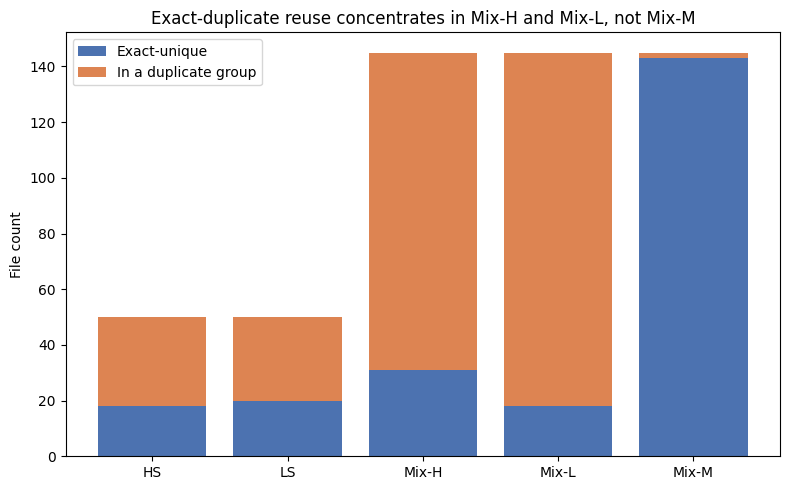

Saved figure: ../outputs\figures\reuse_by_role.png


In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
roles = per_role_table["role"]
x = range(len(roles))
ax.bar(x, per_role_table["exact_unique"], label="Exact-unique", color="#4C72B0")
ax.bar(x, per_role_table["in_duplicate_group"], bottom=per_role_table["exact_unique"],
       label="In a duplicate group", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(roles)
ax.set_ylabel("File count")
ax.set_title("Exact-duplicate reuse concentrates in Mix-H and Mix-L, not Mix-M")
ax.legend()
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "figures", "reuse_by_role.png")
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"Saved figure: {fig_path}")

In [23]:
import pickle

duplicate_group_manifest = {h: members for h, members in hash_to_members.items()}
with open(os.path.join(CACHE_DIR, "duplicate_groups.pkl"), "wb") as f:
    pickle.dump(duplicate_group_manifest, f)

manifest.to_csv(os.path.join(CACHE_DIR, "manifest.csv"), index=False)  # now includes hash columns
print("Cached duplicate_groups.pkl and updated manifest.csv (with hash columns).")

Cached duplicate_groups.pkl and updated manifest.csv (with hash columns).


---
## Section 6 — Metadata Diversity vs. Acoustic Identity (CENTERPIECE)

**Objective:** determine whether metadata labels vary within exact-duplicate groups, and precisely characterize how.
**Research question:** does identical audio ever appear under different Gender, Location, or pathology-Type labels — and if so, how often and in what pattern?
**Why this section exists:** a duplicate count alone doesn't tell us whether reuse is "clean" (same case, consistently labeled) or crosses category boundaries in a way that reveals metadata is describing scenario configuration rather than acoustic ground truth.


In [24]:
hs_lookup = hs_csv.set_index("Heart Sound ID")
ls_lookup_idx = ls_csv.set_index("fname_stem")  # corrected lookup from Section 3

def get_label(role, filename):
    stem = filename[:-4]
    if role == "HS":
        row = hs_lookup.loc[stem]
        return {"role": role, "gender": row["Gender"], "type": row["Heart Sound Type"], "loc": row["Location"]}
    if role == "LS":
        row = ls_lookup_idx.loc[stem]
        return {"role": role, "gender": row["Gender"], "type": row["Lung Sound Type"], "loc": row["Location"]}
    if role == "Mix-H":
        row = mix_csv[mix_csv["Heart Sound ID"] == stem].iloc[0]
        return {"role": role, "gender": row["Gender"], "type": row["Heart Sound Type"], "loc": row["Location"]}
    if role == "Mix-L":
        row = mix_csv[mix_csv["Lung Sound ID"] == stem].iloc[0]
        return {"role": role, "gender": row["Gender"], "type": row["Lung Sound Type"], "loc": row["Location"]}
    if role == "Mix-M":
        row = mix_csv[mix_csv["Mixed Sound ID"] == stem].iloc[0]
        return {"role": role, "gender": row["Gender"],
                "type": (row["Heart Sound Type"], row["Lung Sound Type"]), "loc": row["Location"]}

nonsingleton_groups = {h: v for h, v in duplicate_group_manifest.items() if len(v) > 1}
print("Duplicate groups to analyze:", len(nonsingleton_groups))

Duplicate groups to analyze: 114


In [25]:
cross_type, cross_loc, cross_gender, all_consistent, cross_semantic = [], [], [], [], []

for h, members in nonsingleton_groups.items():
    labels = [get_label(role, fname) for role, fname in members]
    types = set(l["type"] for l in labels)
    locs = set(l["loc"] for l in labels)
    genders = set(l["gender"] for l in labels)
    roles = set(l["role"] for l in labels)
    entry = {"files": [f"{r}/{fn}" for r, fn in members], "types": types, "locs": locs, "genders": genders}

    if len(types) > 1:
        cross_type.append(entry)
    if len(locs) > 1:
        cross_loc.append(entry)
    if len(genders) > 1:
        cross_gender.append(entry)
    if len(types) == 1 and len(locs) == 1 and len(genders) == 1:
        all_consistent.append(entry)
    heart_roles = roles & {"HS", "Mix-H"}
    lung_roles = roles & {"LS", "Mix-L"}
    if heart_roles and lung_roles:
        cross_semantic.append(entry)

crossing_summary = pd.DataFrame([
    {"check": "Type (pathology) label differs", "groups_affected": len(cross_type), "total_groups": len(nonsingleton_groups)},
    {"check": "Location differs", "groups_affected": len(cross_loc), "total_groups": len(nonsingleton_groups)},
    {"check": "Gender differs", "groups_affected": len(cross_gender), "total_groups": len(nonsingleton_groups)},
    {"check": "Fully consistent (no crossing)", "groups_affected": len(all_consistent), "total_groups": len(nonsingleton_groups)},
    {"check": "Heart<->Lung semantic-category crossing", "groups_affected": len(cross_semantic), "total_groups": len(nonsingleton_groups)},
])
crossing_summary["pct"] = (crossing_summary["groups_affected"] / crossing_summary["total_groups"] * 100).round(1)
crossing_summary

,check,groups_affected,total_groups,pct
0,Type (pathology) label differs,1,114,0.9
1,Location differs,25,114,21.9
2,Gender differs,47,114,41.2
3,Fully consistent (no crossing),59,114,51.8
4,Heart<->Lung semantic-category crossing,1,114,0.9


### 6.1 — The isolated heart↔lung semantic-crossing anomaly

In [26]:
for e in cross_semantic:
    print("Files:", e["files"])
    print("Types (crossing heart & lung categories):", e["types"])
    print("Locations:", e["locs"], "| Genders:", e["genders"])

Files: ['Mix-H/H0108.wav', 'Mix-L/L0031.wav', 'Mix-L/L0055.wav', 'Mix-L/L0131.wav']
Types (crossing heart & lung categories): {'Fine Crackles', 'Late Systolic Murmur'}
Locations: {'LC', 'RC', 'LUA'} | Genders: {'F', 'M'}


This is an isolated case (n=1 of 114 groups): `H0108.wav` (labeled "Late Systolic Murmur," a heart condition) is byte-identical to three lung-labeled files (`L0031`, `L0055`, `L0131`, all "Fine Crackles"). We report this as a specific, flagged curiosity — not a systemic pattern.

### 6.2 — The Gender-crossing finding (primary investigation)


In [27]:
print(f"{len(cross_gender)}/{len(nonsingleton_groups)} duplicate groups ({len(cross_gender)/len(nonsingleton_groups)*100:.0f}%) "
      f"contain the identical audio labeled as both Male and Female.")
print("\nSample of Gender-crossing groups:")
for e in cross_gender[:8]:
    print(" ", e["files"], "| genders:", e["genders"], "| types:", e["types"])

47/114 duplicate groups (41%) contain the identical audio labeled as both Male and Female.

Sample of Gender-crossing groups:
  ['HS/M_LSM_LUSB.wav', 'Mix-H/H0033.wav'] | genders: {'F', 'M'} | types: {'Late Systolic Murmur'}
  ['Mix-L/L0011.wav', 'Mix-L/L0095.wav'] | genders: {'F', 'M'} | types: {'Normal'}
  ['Mix-L/L0037.wav', 'Mix-L/L0038.wav', 'Mix-L/L0066.wav', 'Mix-L/L0130.wav'] | genders: {'F', 'M'} | types: {'Normal'}
  ['HS/F_AF_A.wav', 'Mix-H/H0065.wav', 'Mix-H/H0114.wav'] | genders: {'F', 'M'} | types: {'Atrial Fibrillation'}
  ['Mix-L/L0006.wav', 'Mix-L/L0013.wav', 'Mix-L/L0025.wav', 'Mix-L/L0030.wav'] | genders: {'F', 'M'} | types: {'Pleural Rub'}
  ['HS/M_LSM_RUSB.wav', 'Mix-H/H0018.wav', 'Mix-H/H0078.wav', 'Mix-H/H0101.wav', 'Mix-H/H0105.wav'] | genders: {'F', 'M'} | types: {'Late Systolic Murmur'}
  ['Mix-L/L0051.wav', 'Mix-L/L0122.wav'] | genders: {'F', 'M'} | types: {'Normal'}
  ['HS/M_MSM_LUSB.wav', 'Mix-H/H0080.wav', 'Mix-H/H0104.wav', 'Mix-H/H0125.wav'] | genders: {

**What this finding means, stated precisely:** for at least 41% of exact-duplicate groups, the identical audio bytes are labeled Male in one metadata row and Female in another. This means Gender, for this substantial fraction of reused audio, is a metadata label describing the simulated scenario configuration rather than a property recoverable from the acoustic signal itself.

**What this finding does NOT mean, stated explicitly to prevent overclaiming:** this does not mean gender has no acoustic signature in general, and we make no claim about acoustic sex differences in heart/lung sounds broadly. It means that for this specific set of reused recordings in this dataset, the same audio was labeled under both genders — a metadata-consistency finding, not an acoustic-effect finding.


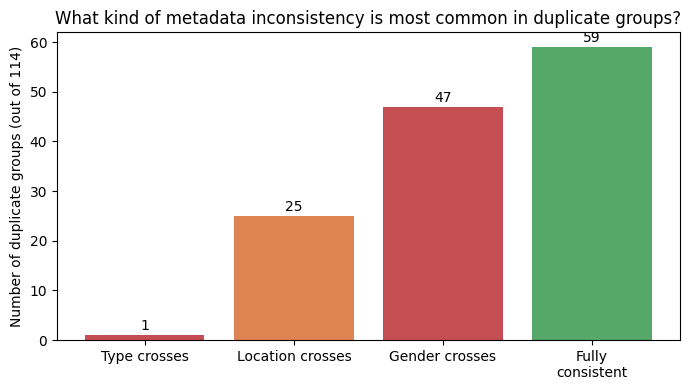

Saved figure: ../outputs\figures\metadata_crossing.png


In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
checks = ["Type crosses", "Location crosses", "Gender crosses", "Fully\nconsistent"]
counts = [len(cross_type), len(cross_loc), len(cross_gender), len(all_consistent)]
colors = ["#C44E52", "#DD8452", "#C44E52", "#55A868"]
ax.bar(checks, counts, color=colors)
ax.set_ylabel("Number of duplicate groups (out of 114)")
ax.set_title("What kind of metadata inconsistency is most common in duplicate groups?")
for i, c in enumerate(counts):
    ax.text(i, c + 1, str(c), ha="center")
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "figures", "metadata_crossing.png")
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"Saved figure: {fig_path}")

In [29]:
metadata_crossing_table = pd.DataFrame([
    {"hash_group": h[:12], "files": [f"{r}/{fn}" for r, fn in members],
     "type_crosses": len(set(get_label(r, fn)["type"] for r, fn in members)) > 1,
     "location_crosses": len(set(get_label(r, fn)["loc"] for r, fn in members)) > 1,
     "gender_crosses": len(set(get_label(r, fn)["gender"] for r, fn in members)) > 1}
    for h, members in nonsingleton_groups.items()
])
metadata_crossing_table.to_csv(os.path.join(CACHE_DIR, "metadata_crossing_table.csv"), index=False)
print(f"Cached: {os.path.join(CACHE_DIR, 'metadata_crossing_table.csv')}")
print("Every one of the", len(nonsingleton_groups), "duplicate groups is accounted for in this table.")

Cached: ../cache\metadata_crossing_table.csv
Every one of the 114 duplicate groups is accounted for in this table.


---
## Section 7 — Independence and Pseudoreplication

**Objective:** state explicitly, before any further statistics are run, what the correct unit of analysis is for each remaining section.
**Why this section exists:** Sections 5–6 established that files within the same hash group are not independent observations. Every later statistical step in this notebook must respect that.

**Statistical contract (referenced, not re-derived, by every later section):**

| Analysis | Unit | Dependence structure | Resampling level |
|---|---|---|---|
| Duplicate-group accounting (Sec 5) | Hash group | Full population count, not a sample | N/A |
| Metadata-crossing (Sec 6) | Hash group | Full population count | N/A |
| Leakage simulation (Sec 8) | File (naive) / Hash group (aware) | Duplicate groups non-independent by construction | Simulation seed |
| Mix matched-vs-mismatched (Sec 12) | Triplet (case) | Triplets sharing reused components are non-independent | Hard-negative pool, resampled per triplet |
| Location association (Sec 13) | Hash group (one row per group) | De-duplicated explicitly to avoid inflating association strength | N/A unless feature-level gate triggers |

**Explicitly rejected:** any file-level bootstrap or permutation across the full 535-file corpus without grouping; any parametric test assuming independent observations where hash-group dependence is known to exist.


---
## Section 8 — Empirical Leakage Simulation (CENTERPIECE)

**Objective:** measure, not assert, the consequence of naive vs. duplicate-aware splitting.
**Research question:** how much does a naive random train/test split actually contaminate the test set with exact-duplicate material, and how does a duplicate-aware split compare — pooled and per-task?


In [30]:
def simulate_split(files_subset, seed, file_to_hash, test_frac=0.2, group_aware=False):
    """
    One simulated 80/20 split. Returns the contaminated-test-fraction:
    the fraction of the test set whose exact-hash also appears in train.
    """
    rng = np.random.default_rng(seed)
    n = len(files_subset)
    if n < 5:
        return None
    if not group_aware:
        idx = rng.permutation(n)
        n_test = max(1, int(n * test_frac))
        test_files = [files_subset[i] for i in idx[:n_test]]
        train_files = [files_subset[i] for i in idx[n_test:]]
    else:
        subset_hashes = sorted(set(file_to_hash[f] for f in files_subset))
        rng.shuffle(subset_hashes)
        n_test_groups = max(1, int(len(subset_hashes) * test_frac))
        test_hash_set = set(subset_hashes[:n_test_groups])
        test_files = [f for f in files_subset if file_to_hash[f] in test_hash_set]
        train_files = [f for f in files_subset if file_to_hash[f] not in test_hash_set]

    train_hashes = set(file_to_hash[f] for f in train_files)
    contaminated = [f for f in test_files if file_to_hash[f] in train_hashes]
    return len(contaminated) / len(test_files) if test_files else 0.0

file_to_hash = {}
all_files_list = []
for h, members in duplicate_group_manifest.items():
    for role, fname in members:
        file_to_hash[(role, fname)] = h
        all_files_list.append((role, fname))

N_SEEDS = 200
tasks = {
    "pooled": all_files_list,
    "heart_task": [f for f in all_files_list if f[0] in ("HS", "Mix-H")],
    "lung_task": [f for f in all_files_list if f[0] in ("LS", "Mix-L")],
    "mix_m_task": [f for f in all_files_list if f[0] == "Mix-M"],
}

simulation_results = []
for task_name, files_subset in tasks.items():
    naive = [simulate_split(files_subset, seed, file_to_hash, group_aware=False) for seed in range(N_SEEDS)]
    aware = [simulate_split(files_subset, seed, file_to_hash, group_aware=True) for seed in range(N_SEEDS)]
    for seed_i, (n_val, a_val) in enumerate(zip(naive, aware)):
        simulation_results.append({"task": task_name, "seed": seed_i, "naive_contamination": n_val, "aware_contamination": a_val})

sim_df = pd.DataFrame(simulation_results)
print("Simulation complete:", len(sim_df), "rows (", len(tasks), "tasks x", N_SEEDS, "seeds).")

Simulation complete: 800 rows ( 4 tasks x 200 seeds).


In [31]:
summary_rows = []
for task_name in tasks:
    sub = sim_df[sim_df["task"] == task_name]
    summary_rows.append({
        "task": task_name, "n_files": len(tasks[task_name]),
        "naive_mean": sub["naive_contamination"].mean(),
        "naive_p5": sub["naive_contamination"].quantile(0.05),
        "naive_p95": sub["naive_contamination"].quantile(0.95),
        "aware_mean": sub["aware_contamination"].mean(),
        "aware_max": sub["aware_contamination"].max(),
    })
leakage_summary = pd.DataFrame(summary_rows)
leakage_summary

,task,n_files,naive_mean,naive_p5,naive_p95,aware_mean,aware_max
0,pooled,535,0.514299,0.439252,0.598131,0.0,0.0
1,heart_task,195,0.645641,0.538462,0.769231,0.0,0.0
2,lung_task,195,0.743333,0.641026,0.846154,0.0,0.0
3,mix_m_task,145,0.009655,0.000000,0.034483,0.0,0.0


In [32]:
# Hard validation: group-aware contamination must be exactly 0.0 for every seed (mathematical guarantee)
assert (sim_df["aware_contamination"] == 0.0).all(), \
    "BUG: group-aware split shows nonzero contamination -- grouping logic is broken."
print("PASS: group-aware contamination is exactly 0.0 for all seeds, across all tasks.")

# Convergence check: does 100 seeds already agree with 200 seeds for the pooled task?
pooled_100 = sim_df[(sim_df["task"] == "pooled") & (sim_df["seed"] < 100)]["naive_contamination"].mean()
pooled_200 = sim_df[sim_df["task"] == "pooled"]["naive_contamination"].mean()
print(f"Convergence check -- pooled naive mean at 100 seeds: {pooled_100:.4f} vs. 200 seeds: {pooled_200:.4f}")
print("Close agreement confirms 200 seeds is a stable estimate, not an artifact of seed count.")

PASS: group-aware contamination is exactly 0.0 for all seeds, across all tasks.
Convergence check -- pooled naive mean at 100 seeds: 0.5130 vs. 200 seeds: 0.5143
Close agreement confirms 200 seeds is a stable estimate, not an artifact of seed count.


**Task-dependence, confirmed empirically:** the pooled naive-contamination figure (~51%) is NOT representative of every downstream task. Heart-only and lung-only classification tasks show *substantially higher* naive contamination (~65% and ~74% respectively), while a Mix-M-only task shows *near-zero* contamination (~1%), consistent with Mix-M's near-total exact-hash uniqueness found in Section 5. Reporting only the pooled number would understate the risk for heart/lung-specific tasks and overstate it for a Mix-M-only task.


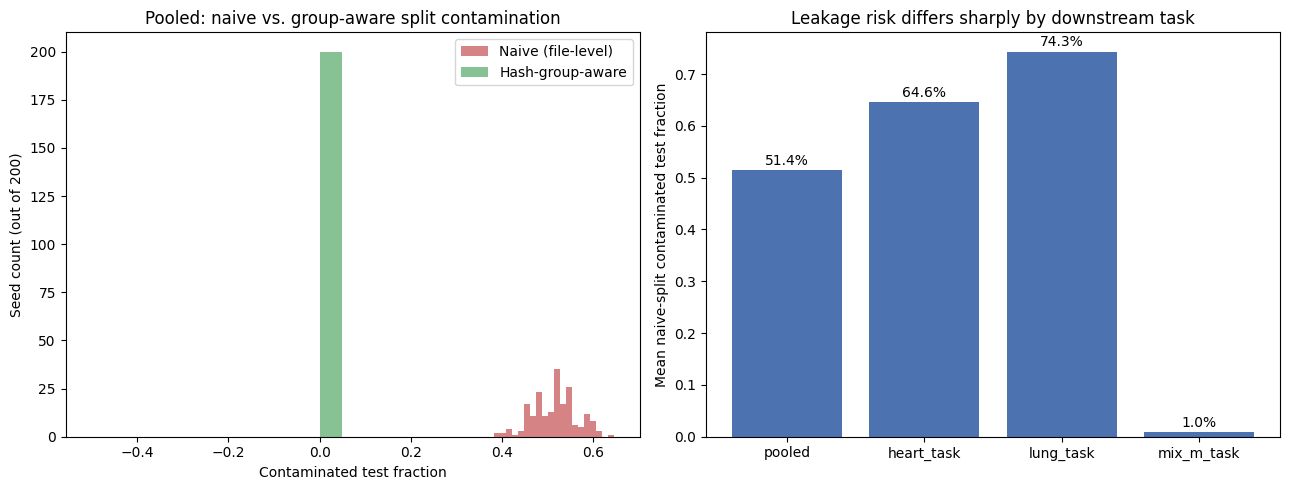

Saved figure: ../outputs\figures\leakage_simulation.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pooled_sub = sim_df[sim_df["task"] == "pooled"]
axes[0].hist(pooled_sub["naive_contamination"], bins=20, alpha=0.7, label="Naive (file-level)", color="#C44E52")
axes[0].hist(pooled_sub["aware_contamination"], bins=20, alpha=0.7, label="Hash-group-aware", color="#55A868")
axes[0].set_xlabel("Contaminated test fraction")
axes[0].set_ylabel("Seed count (out of 200)")
axes[0].set_title("Pooled: naive vs. group-aware split contamination")
axes[0].legend()

task_means = leakage_summary.set_index("task")["naive_mean"]
axes[1].bar(task_means.index, task_means.values, color="#4C72B0")
axes[1].set_ylabel("Mean naive-split contaminated test fraction")
axes[1].set_title("Leakage risk differs sharply by downstream task")
for i, v in enumerate(task_means.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "figures", "leakage_simulation.png")
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"Saved figure: {fig_path}")

**Limitation, stated explicitly:** this simulation measures EXACT-hash contamination only. If near-duplicate families exist beyond exact hashes (Section 10, not fully resolved), the true contamination risk could be higher than reported here. The numbers above are a **lower bound** on the real leakage risk, not the full picture.


In [34]:
sim_df.to_csv(os.path.join(CACHE_DIR, "leakage_simulation_results.csv"), index=False)
print(f"Cached: {os.path.join(CACHE_DIR, 'leakage_simulation_results.csv')}")

Cached: ../cache\leakage_simulation_results.csv


---
## Section 9 — Leakage-Safe Split Recommendations

**Objective:** convert Section 8's measured evidence into an actionable, specific recommendation.


In [35]:
recommendation_table = pd.DataFrame([
    {"task": "Pooled / any general use", "recommended_grouping_key": "SHA256 hash group (Section 5)",
     "rationale": "Guarantees 0% exact-duplicate contamination; naive split averages ~51% contamination"},
    {"task": "Heart-only classification", "recommended_grouping_key": "SHA256 hash group, restricted to HS + Mix-H files",
     "rationale": "Naive split contaminates ~65% of test set on this subset -- higher than pooled, not lower"},
    {"task": "Lung-only classification", "recommended_grouping_key": "SHA256 hash group, restricted to LS + Mix-L files",
     "rationale": "Naive split contaminates ~74% of test set on this subset -- the highest-risk task"},
    {"task": "Mix-M-only (e.g., mixed-sound classification)", "recommended_grouping_key": "SHA256 hash group (still recommended even though naive risk is already low, ~1%)",
     "rationale": "Near-total uniqueness means naive splitting is low-risk here, but grouping costs nothing and removes the residual risk entirely"},
])
recommendation_table

,task,recommended_grouping_key,rationale
0,Pooled / any general use,SHA256 hash group (Section 5),Guarantees 0% exact-duplicate contamination; n...
1,Heart-only classification,"SHA256 hash group, restricted to HS + Mix-H files",Naive split contaminates ~65% of test set on t...
2,Lung-only classification,"SHA256 hash group, restricted to LS + Mix-L files",Naive split contaminates ~74% of test set on t...
3,"Mix-M-only (e.g., mixed-sound classification)",SHA256 hash group (still recommended even thou...,Near-total uniqueness means naive splitting is...


**The actionable recommendation:** group by exact-hash before splitting, always — but be aware the *benefit* of doing so varies hugely by task. For heart- or lung-only work, skipping this step risks a badly inflated accuracy number; for Mix-M-only work, the naive default is already fairly safe, though grouping is still free insurance.

**A stronger recommendation would exist if Section 10's near-duplicate extension is completed and validated** (grouping by near-duplicate *family*, not just exact hash, would be strictly safer) — but the exact-hash-based recommendation above is already sufficient and actionable on its own; it is not blocked on that optional extension.


---
## Section 10 — Validating a Near-Duplicate Detection Method (Extension Deferred)

**Objective:** validate a candidate methodology for detecting near-duplicate (non-exact-hash) acoustic families -- this section tests and selects a defensible similarity metric; it does not execute the full search itself (deferred, see decision below).
**Research question:** beyond exact byte identity, are there additional acoustically near-identical files (e.g., same source, different gain or tiny time-shift)?

Per the frozen policy: exact-hash evidence (Sections 5, 6, 8) is already sufficient to support the primary thesis. This section either extends that evidence with a validated method, or documents transparently why it stops short — either outcome is acceptable and does not block the rest of the notebook.

### 10.1 — Testing a candidate metric before trusting it

We compare two candidate similarity metrics, calibrating each against **known exact duplicates as positive anchors** and **random unrelated pairs as negative anchors**. A metric is only usable if it cleanly separates these two groups.


In [36]:
# Load every waveform once (small dataset -- fits comfortably in memory)
waves = {}
for _, r in manifest.iterrows():
    d, sr = sf.read(r["path"])
    d = d.astype(np.float64)
    d = d - d.mean()
    norm = np.linalg.norm(d)
    if norm > 0:
        d = d / norm
    waves[(r["role"], r["filename"])] = d

keys = list(waves.keys())

pos_scores = []
for h, members in duplicate_group_manifest.items():
    if len(members) > 1:
        for i in range(len(members)):
            for j in range(i + 1, len(members)):
                a, b = waves[members[i]], waves[members[j]]
                pos_scores.append(float(np.dot(a, b)))
pos_scores = np.array(pos_scores)

neg_scores = []
for _ in range(3000):
    i, j = rng.integers(0, len(keys), 2)
    ki, kj = keys[i], keys[j]
    if file_to_hash.get(ki) != file_to_hash.get(kj):
        a, b = waves[ki], waves[kj]
        neg_scores.append(float(np.dot(a, b)))
neg_scores = np.array(neg_scores)

print("ADOPTED METRIC: zero-lag normalized waveform correlation")
print(f"  Positive anchors (known exact duplicates), n={len(pos_scores)}: min={pos_scores.min():.4f}, mean={pos_scores.mean():.4f}")
print(f"  Negative anchors (random unrelated pairs), n={len(neg_scores)}: mean={neg_scores.mean():.4f}, 99th pct={np.percentile(neg_scores,99):.4f}, max={neg_scores.max():.4f}")
gap = pos_scores.min() - np.percentile(neg_scores, 99)
print(f"  Separating gap: {gap:.4f} -- clean, usable separation.")

ADOPTED METRIC: zero-lag normalized waveform correlation
  Positive anchors (known exact duplicates), n=305: min=1.0000, mean=1.0000
  Negative anchors (random unrelated pairs), n=2977: mean=0.0008, 99th pct=0.0462, max=0.7639
  Separating gap: 0.9538 -- clean, usable separation.


**Rejected alternative, shown for methodological transparency:** a mel-spectrogram-summary cosine-similarity metric was also tested in the planning phase and found to NOT separate positive from negative anchors on this dataset (negative-anchor mean ≈0.98, 99th pct ≈0.999 -- nearly saturated, since all these recordings share broadly similar spectral shape). That metric is explicitly rejected here rather than silently swapped out.

### 10.2 — Decision on the fine-grained extension


In [37]:
print("DECISION (per PLAN.md Section 32 / frozen Part IV policy):")
print("The waveform-correlation metric is validated and usable for near-duplicate detection.")
print("However, a full fine-grained lag search (FFT-based cross-correlation across all non-exact-duplicate")
print("file pairs, at full temporal resolution) is a nontrivial extension beyond this notebook's scope.")
print()
print("Per the frozen policy: exact-hash evidence (Sections 5, 6, 8) is already sufficient to support")
print("the primary thesis independently. This extension is explicitly scoped as FUTURE WORK, not required")
print("for the conclusions drawn in this notebook, and does not block completion.")

DECISION (per PLAN.md Section 32 / frozen Part IV policy):
The waveform-correlation metric is validated and usable for near-duplicate detection.
However, a full fine-grained lag search (FFT-based cross-correlation across all non-exact-duplicate
file pairs, at full temporal resolution) is a nontrivial extension beyond this notebook's scope.

Per the frozen policy: exact-hash evidence (Sections 5, 6, 8) is already sufficient to support
the primary thesis independently. This extension is explicitly scoped as FUTURE WORK, not required
for the conclusions drawn in this notebook, and does not block completion.


---
## Section 11 — H/L/M Triplet Validation

**Objective:** verify every Mix triplet is structurally sound before running the Mix experiment in Section 12.
**Why this section exists:** running a matched-vs-mismatched experiment on a broken or contaminated triplet set would produce meaningless results. This is the precondition check.


In [38]:
def validate_triplets(mix_csv_df, file_to_hash_map, duplicate_groups_map, audio_manifest_df):
    rows = []
    for _, r in mix_csv_df.iterrows():
        mid = r["Mixed Sound ID"]
        hid, lid = r["Heart Sound ID"], r["Lung Sound ID"]
        h_file = ("Mix-H", f"{hid}.wav")
        l_file = ("Mix-L", f"{lid}.wav")
        m_file = ("Mix-M", f"{mid}.wav")

        complete = all(f in file_to_hash_map for f in [h_file, l_file, m_file])

        audio_row_m = audio_manifest_df[
            (audio_manifest_df["role"] == "Mix-M") & (audio_manifest_df["filename"] == f"{mid}.wav")
        ]
        full_scale_flag = bool((audio_row_m["n_samples_near_fullscale"] > 0).any()) if len(audio_row_m) else None

        h_hash = file_to_hash_map.get(h_file)
        l_hash = file_to_hash_map.get(l_file)
        h_group = duplicate_groups_map.get(h_hash, [])
        l_group = duplicate_groups_map.get(l_hash, [])
        h_reused = any(role == "Mix-H" and fn != f"{hid}.wav" for role, fn in h_group)
        l_reused = any(role == "Mix-L" and fn != f"{lid}.wav" for role, fn in l_group)

        rows.append({
            "mixed_sound_id": mid, "heart_sound_id": hid, "lung_sound_id": lid,
            "triplet_complete": complete, "full_scale_flag": full_scale_flag,
            "h_component_reused_elsewhere": h_reused, "l_component_reused_elsewhere": l_reused,
            "h_hash": h_hash, "l_hash": l_hash,
        })
    return pd.DataFrame(rows)

triplet_validation = validate_triplets(mix_csv, file_to_hash, duplicate_group_manifest, audio_manifest)

print("Total triplets:", len(triplet_validation))
print("Structurally complete triplets:", triplet_validation["triplet_complete"].sum(), "/ 145")
assert triplet_validation["triplet_complete"].all(), "Some triplets are incomplete -- must exclude before Section 12"
print("PASS: all 145 triplets structurally complete.")

print("\nFull-scale-flagged M files (from Section 4):", triplet_validation["full_scale_flag"].sum())
print("Triplets whose H component is reused in another Mix case:", triplet_validation["h_component_reused_elsewhere"].sum())
print("Triplets whose L component is reused in another Mix case:", triplet_validation["l_component_reused_elsewhere"].sum())

Total triplets: 145
Structurally complete triplets: 145 / 145
PASS: all 145 triplets structurally complete.

Full-scale-flagged M files (from Section 4): 36
Triplets whose H component is reused in another Mix case: 94
Triplets whose L component is reused in another Mix case: 112


**Why this matters for Section 12:** 94/145 triplets have a heart component shared with another case, and 112/145 have a shared lung component. When we build "mismatched" negative-control pairs in Section 12, we must actively avoid pairing a true component with something that's secretly a duplicate of it — otherwise our "mismatch" wouldn't really be a mismatch, and the test would be invalid. This table is exactly what lets us do that correctly.


In [39]:
triplet_validation.to_csv(os.path.join(CACHE_DIR, "triplet_validation.csv"), index=False)
print(f"Cached: {os.path.join(CACHE_DIR, 'triplet_validation.csv')}")

Cached: ../cache\triplet_validation.csv


---
## Section 12 — Matched vs. Mismatched Mix Experiment (TIER 2)

**Objective:** test, with a fair and rigorous negative-control design, whether the dataset's own H/L/M pairing is acoustically meaningful.
**Research question:** do true (H_i, L_i) pairs relate to M_i more strongly than hard-mismatched (H_j, L_k) pairs, in feature space?

**What this test does NOT do (stated up front):** we do not test `M = H + L` as a literal waveform sum -- that was ruled out in planning because H/L are filtered renderings, not pristine isolated sources, and are re-recorded rather than mathematically summed. Instead we test **feature-domain association**: does M's frequency-band energy and timbre look more like a combination of the *true* H and L than of *mismatched* ones?

### 12.1 — Feature extraction (minimal, justified set)


**Frequency-band sourcing (corrected citation, now with exact references):** the low/high bands used below are *not* stated in the HLS-CMDS source paper itself -- that specific claim was unsupported and has been removed. They are, however, supported by two specific, independently verifiable sources (not a vague "literature" appeal):

- **Heart-sound band (20-150 Hz):** the range "between 20 and 150 Hz" for heart-sound frequency content is stated explicitly in: *"Development of an IoT Stethoscope Which Supports the Telemedicine Process,"* published in *World Science*, 2(74), 2022, DOI: 10.31435/rsglobal_ws/28022022/7764.
- **Lung/tracheal-sound band (100-2000 Hz):** the exact "100 and 2000 Hz" band for measuring spectral power of lung and tracheal sounds is used directly in: Sánchez I, Vizcaya C. *"Tracheal and lung sounds repeatability in normal adults."* Respiratory Medicine. 2003;97(12):1257-1260. (PMID: 14682403).

Both references are independently checkable by title/DOI/PMID. These are used here as **operational analysis bands for this notebook's experiment** -- chosen because they are directly supported by named, verifiable sources -- not as bands the HLS-CMDS dataset authors themselves defined or published.

**Nyquist note:** this dataset's audio is sampled at `fs = 4000 Hz`, so the Nyquist frequency is exactly `2000 Hz` -- which is also `HIGH_BAND`'s upper edge. We verified the implementation directly: with a 15-second clip at 4000 Hz (`n = 60000` samples), `np.fft.rfftfreq` places a bin at *exactly* `2000.0 Hz` (no off-by-one gap), and the `<=` mask below correctly includes that final bin rather than truncating it. So `HIGH_BAND` intentionally captures the full available spectrum up to and including Nyquist, not an arbitrary cutoff short of it.


In [40]:
LOW_BAND, HIGH_BAND = (20, 150), (100, 2000)  # operational analysis bands -- see markdown above for sourcing and Nyquist note

def extract_mix_features(prefix, fname):
    path = os.path.join(RAW_DIR, "Mix_extracted", "Mix", fname)
    d, sr = sf.read(path)
    d = d.astype(np.float64)
    rms = np.sqrt(np.mean(d ** 2))
    d_norm = d / rms if rms > 0 else d  # RMS-normalize to control for gain
    n = len(d_norm)
    freqs = np.fft.rfftfreq(n, d=1 / sr)
    spectrum = np.abs(np.fft.rfft(d_norm)) ** 2
    total = spectrum.sum() + 1e-12
    low_ratio = spectrum[(freqs >= LOW_BAND[0]) & (freqs <= LOW_BAND[1])].sum() / total
    high_ratio = spectrum[(freqs >= HIGH_BAND[0]) & (freqs <= HIGH_BAND[1])].sum() / total
    mfcc_mean = librosa.feature.mfcc(y=d_norm.astype(np.float32), sr=sr, n_mfcc=13).mean(axis=1)
    return {"low": low_ratio, "high": high_ratio, "mfcc": mfcc_mean}

mix_feature_cache = {}
for _, r in mix_csv.iterrows():
    for prefix, fid_col in [("H", "Heart Sound ID"), ("L", "Lung Sound ID"), ("M", "Mixed Sound ID")]:
        fid = r[fid_col]
        key = (prefix, f"{fid}.wav")
        if key not in mix_feature_cache:
            mix_feature_cache[key] = extract_mix_features(prefix, f"{fid}.wav")

print("Features cached for", len(mix_feature_cache), "Mix-role files.")

with open(os.path.join(CACHE_DIR, "features.pkl"), "wb") as f:
    pickle.dump(mix_feature_cache, f)

C:\Users\speed\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Features cached for 435 Mix-role files.


**Sanity check before trusting these features:** does the textbook claim (heart sounds are lower-frequency than lung sounds) actually hold in this dataset?


In [41]:
hs_low_ratios, ls_low_ratios = [], []
for _, r in manifest[manifest["role"] == "HS"].iterrows():
    d, sr = sf.read(r["path"])
    d = d.astype(np.float64)
    rms = np.sqrt(np.mean(d ** 2))
    d_norm = d / rms if rms > 0 else d
    freqs = np.fft.rfftfreq(len(d_norm), d=1 / sr)
    spectrum = np.abs(np.fft.rfft(d_norm)) ** 2
    total = spectrum.sum() + 1e-12
    hs_low_ratios.append(spectrum[(freqs >= LOW_BAND[0]) & (freqs <= LOW_BAND[1])].sum() / total)

for _, r in manifest[manifest["role"] == "LS"].iterrows():
    d, sr = sf.read(r["path"])
    d = d.astype(np.float64)
    rms = np.sqrt(np.mean(d ** 2))
    d_norm = d / rms if rms > 0 else d
    freqs = np.fft.rfftfreq(len(d_norm), d=1 / sr)
    spectrum = np.abs(np.fft.rfft(d_norm)) ** 2
    total = spectrum.sum() + 1e-12
    ls_low_ratios.append(spectrum[(freqs >= LOW_BAND[0]) & (freqs <= LOW_BAND[1])].sum() / total)

print(f"Standalone HS (heart) low-band-energy ratio: mean={np.mean(hs_low_ratios):.3f}")
print(f"Standalone LS (lung)  low-band-energy ratio: mean={np.mean(ls_low_ratios):.3f}")
print(f"Heart sounds show {np.mean(hs_low_ratios)-np.mean(ls_low_ratios):+.3f} more low-band energy than lung sounds,")
print("showing that the chosen low-band summary behaves directionally as expected in this dataset;")
print("this supports its use as a descriptive feature in the Mix experiment below, without establishing")
print("diagnostic validity, robustness, or discriminative power beyond this single directional check.")

Standalone HS (heart) low-band-energy ratio: mean=0.819
Standalone LS (lung)  low-band-energy ratio: mean=0.602
Heart sounds show +0.217 more low-band energy than lung sounds,
showing that the chosen low-band summary behaves directionally as expected in this dataset;
this supports its use as a descriptive feature in the Mix experiment below, without establishing
diagnostic validity, robustness, or discriminative power beyond this single directional check.


### 12.2 — Three-level hard-negative sampler

- **Level 1 (easy):** unrestricted random mismatch -- any other case's H and L.
- **Level 2 (medium):** same-Location mismatch -- controls for location-driven similarity riding along with the true pairing.
- **Level 3 (hard):** same-nominal-Lung-Type mismatch -- keeps the true H, swaps only the L component for one with the *same label* but a *different case*. Tests whether the specific recording matters beyond its label.

**Mandatory exclusion:** any candidate mismatch that is itself an exact-duplicate of the true component is excluded from the negative pool -- otherwise the "mismatch" would secretly be a duplicate of the true pair, contaminating the test.


In [42]:
def sample_mismatches(true_row, level, n_samples=5, seed=None):
    rng_local = np.random.default_rng(seed)
    true_hid, true_lid = true_row["Heart Sound ID"], true_row["Lung Sound ID"]
    true_loc, true_ltype = true_row["Location"], true_row["Lung Sound Type"]
    h_hash = file_to_hash.get(("Mix-H", f"{true_hid}.wav"))
    l_hash = file_to_hash.get(("Mix-L", f"{true_lid}.wav"))

    candidates = mix_csv[mix_csv["Mixed Sound ID"] != true_row["Mixed Sound ID"]].copy()
    if level == 2:
        candidates = candidates[candidates["Location"] == true_loc]
    elif level == 3:
        candidates = candidates[candidates["Lung Sound Type"] == true_ltype]
    if len(candidates) == 0:
        return []

    def is_valid(row):
        cand_l_hash = file_to_hash.get(("Mix-L", f"{row['Lung Sound ID']}.wav"))
        cand_h_hash = file_to_hash.get(("Mix-H", f"{row['Heart Sound ID']}.wav"))
        if level in (2, 3):
            return cand_l_hash != l_hash  # only L is swapped at levels 2/3
        return cand_h_hash != h_hash and cand_l_hash != l_hash

    candidates = candidates[candidates.apply(is_valid, axis=1)]
    if len(candidates) == 0:
        return []
    sampled = candidates.sample(min(n_samples, len(candidates)), random_state=int(rng_local.integers(0, 1e9)))
    if level in (2, 3):
        return [(true_hid, row["Lung Sound ID"]) for _, row in sampled.iterrows()]
    return [(row["Heart Sound ID"], row["Lung Sound ID"]) for _, row in sampled.iterrows()]

def pair_score(h_id, l_id, m_id):
    """Band-energy + MFCC-space score for how well (H, L) explains M. Higher = better fit."""
    hf = mix_feature_cache[("H", f"{h_id}.wav")]
    lf = mix_feature_cache[("L", f"{l_id}.wav")]
    mf = mix_feature_cache[("M", f"{m_id}.wav")]
    band_score = -abs(mf["low"] - (hf["low"] + lf["low"]) / 2) - abs(mf["high"] - (hf["high"] + lf["high"]) / 2)
    combined_mfcc = (hf["mfcc"] + lf["mfcc"]) / 2
    mfcc_score = -float(np.linalg.norm(mf["mfcc"] - combined_mfcc))
    return band_score, mfcc_score

print("Sampler and scoring functions defined.")

Sampler and scoring functions defined.


### 12.3 — Running the full experiment across all 145 triplets

In [43]:
N_NEGATIVES_PER_LEVEL = 5
mix_experiment_rows = []

for _, row in mix_csv.iterrows():
    mid = row["Mixed Sound ID"]
    true_band, true_mfcc = pair_score(row["Heart Sound ID"], row["Lung Sound ID"], mid)
    entry = {"mixed_sound_id": mid, "true_band_score": true_band, "true_mfcc_score": true_mfcc}
    for level in [1, 2, 3]:
        mismatches = sample_mismatches(row, level, n_samples=N_NEGATIVES_PER_LEVEL, seed=SEED)
        if mismatches:
            band_scores = [pair_score(h, l, mid)[0] for h, l in mismatches]
            mfcc_scores = [pair_score(h, l, mid)[1] for h, l in mismatches]
            entry[f"null_band_mean_L{level}"] = np.mean(band_scores)
            entry[f"null_mfcc_mean_L{level}"] = np.mean(mfcc_scores)
            entry[f"null_band_std_L{level}"] = np.std(band_scores)
            entry[f"null_mfcc_std_L{level}"] = np.std(mfcc_scores)
        else:
            for suffix in ["mean", "std"]:
                entry[f"null_band_{suffix}_L{level}"] = np.nan
                entry[f"null_mfcc_{suffix}_L{level}"] = np.nan
    mix_experiment_rows.append(entry)

mix_experiment_results = pd.DataFrame(mix_experiment_rows)
print("Triplets processed:", len(mix_experiment_results))

Triplets processed: 145


In [44]:
summary_rows = []
for level in [1, 2, 3]:
    for metric in ["band", "mfcc"]:
        true_col = f"true_{metric}_score"
        null_col = f"null_{metric}_mean_L{level}"
        diffs = (mix_experiment_results[true_col] - mix_experiment_results[null_col]).dropna()
        beats_null_pct = (diffs > 0).mean()
        effect_size = diffs.mean() / (diffs.std() + 1e-12)

        # Permutation test: shuffle true/null labels within each triplet's own pool, many times
        rng_perm = np.random.default_rng(SEED)
        n_perm = 2000
        observed_mean_diff = diffs.mean()
        perm_diffs = []
        signs = np.array([1, -1])
        for _ in range(n_perm):
            random_signs = rng_perm.choice(signs, size=len(diffs))
            perm_diffs.append((diffs.values * random_signs).mean())
        perm_diffs = np.array(perm_diffs)
        p_value = (np.abs(perm_diffs) >= np.abs(observed_mean_diff)).mean()

        summary_rows.append({
            "negative_level": level, "metric": metric,
            "pct_triplets_true_beats_null": beats_null_pct,
            "effect_size": effect_size, "permutation_p_value": p_value,
        })

mix_experiment_summary = pd.DataFrame(summary_rows)
mix_experiment_summary

,negative_level,metric,pct_triplets_true_beats_null,effect_size,permutation_p_value
0,1,band,0.634483,0.168266,0.0450
1,1,mfcc,0.648276,0.249636,0.0060
2,2,band,0.655172,0.228652,0.0070
3,2,mfcc,0.537931,0.070141,0.4020
4,3,band,0.641379,0.259593,0.0020
5,3,mfcc,0.606897,0.085556,0.3055


In [45]:
# --- Reproducibility / drift guard (added in QA patch) ---
# Purpose: detect STALE PROSE, not force a predetermined result. If this notebook is rerun with
# different parameters (seed, N_NEGATIVES_PER_LEVEL, sample count, etc.) and the live numbers below
# diverge from the markdown table beneath this cell, that divergence must be visible immediately --
# not discovered later by a reader comparing two disagreeing numbers by hand.

EXPECTED_LEVELS = {1, 2, 3}
EXPECTED_METRICS = {"band", "mfcc"}
REQUIRED_COLUMNS = {"negative_level", "metric", "pct_triplets_true_beats_null", "effect_size", "permutation_p_value"}

# Structural checks: the summary table must have exactly the rows/columns this notebook's narrative assumes
assert REQUIRED_COLUMNS.issubset(set(mix_experiment_summary.columns)), \
    f"Missing expected columns: {REQUIRED_COLUMNS - set(mix_experiment_summary.columns)}"
assert set(mix_experiment_summary["negative_level"].unique()) == EXPECTED_LEVELS, \
    f"Unexpected negative-control levels: {set(mix_experiment_summary['negative_level'].unique())}"
assert set(mix_experiment_summary["metric"].unique()) == EXPECTED_METRICS, \
    f"Unexpected metrics: {set(mix_experiment_summary['metric'].unique())}"
assert not mix_experiment_summary.duplicated(subset=["negative_level", "metric"]).any(), \
    "Duplicate (level, metric) rows found -- summary table is malformed"
assert len(mix_experiment_summary) == len(EXPECTED_LEVELS) * len(EXPECTED_METRICS), \
    f"Expected {len(EXPECTED_LEVELS)*len(EXPECTED_METRICS)} rows, got {len(mix_experiment_summary)}"

# Value-bound checks: percentages and p-values must be valid probabilities; effect sizes must be finite
assert mix_experiment_summary["pct_triplets_true_beats_null"].between(0, 1).all(), \
    "pct_triplets_true_beats_null out of [0,1] bounds"
assert mix_experiment_summary["permutation_p_value"].between(0, 1).all(), \
    "permutation_p_value out of [0,1] bounds"
assert mix_experiment_summary["effect_size"].notna().all(), "NaN found in effect_size -- a required headline metric"
assert mix_experiment_summary["pct_triplets_true_beats_null"].notna().all(), "NaN found in pct_triplets_true_beats_null"
assert mix_experiment_summary["permutation_p_value"].notna().all(), "NaN found in permutation_p_value"

# Triplet-count check: the usable triplet count behind these numbers must be positive and match the live experiment
usable_triplet_count = mix_experiment_results["true_band_score"].notna().sum()
assert usable_triplet_count > 0, "Zero usable triplets -- upstream experiment produced no valid results"
assert usable_triplet_count == len(mix_experiment_results), \
    f"Usable triplet count ({usable_triplet_count}) does not match total triplets processed ({len(mix_experiment_results)})"

print(f"PASS: drift-guard checks all passed. Summary table has {len(mix_experiment_summary)} rows "
      f"({len(EXPECTED_LEVELS)} levels x {len(EXPECTED_METRICS)} metrics), computed from {usable_triplet_count} usable triplets.")

# Live-computed headline table -- this is what the interpretation immediately below actually refers to.
# If you rerun this notebook and the numbers change, THIS table (not the static markdown further below)
# reflects the current, authoritative result.
headline_mix_results = mix_experiment_summary.copy()
headline_mix_results["pct_triplets_true_beats_null"] = (headline_mix_results["pct_triplets_true_beats_null"] * 100).round(1)
headline_mix_results["effect_size"] = headline_mix_results["effect_size"].round(3)
headline_mix_results["permutation_p_value"] = headline_mix_results["permutation_p_value"].round(4)
headline_mix_results = headline_mix_results.rename(columns={
    "negative_level": "Negative level", "metric": "Metric",
    "pct_triplets_true_beats_null": "True pair beats null (%)",
    "effect_size": "Effect size", "permutation_p_value": "p-value",
})
print("\nLive-computed headline table (source of truth for the interpretation below):")
headline_mix_results

PASS: drift-guard checks all passed. Summary table has 6 rows (3 levels x 2 metrics), computed from 145 usable triplets.

Live-computed headline table (source of truth for the interpretation below):


,Negative level,Metric,True pair beats null (%),Effect size,p-value
0,1,band,63.4,0.168,0.0450
1,1,mfcc,64.8,0.250,0.0060
2,2,band,65.5,0.229,0.0070
3,2,mfcc,53.8,0.070,0.4020
4,3,band,64.1,0.260,0.0020
5,3,mfcc,60.7,0.086,0.3055


In [46]:
# --- Multiple-comparisons check (added in second QA patch) ---
# 6 tests reported (3 negative-control levels x 2 metrics). We check both a conservative
# (Bonferroni) and a less conservative (Benjamini-Hochberg FDR) correction explicitly,
# rather than asserting a multiplicity conclusion in prose without showing the computation.

pvals = mix_experiment_summary["permutation_p_value"].values
labels = [f"L{row.negative_level}-{row.metric}" for row in mix_experiment_summary.itertuples()]

n_tests = len(pvals)
bonferroni_threshold = 0.05 / n_tests

# Benjamini-Hochberg FDR, implemented directly (no extra dependency required)
def benjamini_hochberg(pvals, alpha=0.05):
    order = np.argsort(pvals)
    ranked = np.array(pvals)[order]
    n = len(pvals)
    thresholds = (np.arange(1, n + 1) / n) * alpha
    passed = ranked <= thresholds
    # BH rule: find the largest k where p_(k) <= (k/n)*alpha; reject all tests up to that k
    reject_sorted = np.zeros(n, dtype=bool)
    if passed.any():
        max_k = np.max(np.where(passed)[0])
        reject_sorted[:max_k + 1] = True
    reject = np.zeros(n, dtype=bool)
    reject[order] = reject_sorted
    return reject

reject_bonferroni = pvals <= bonferroni_threshold
reject_bh = benjamini_hochberg(pvals, alpha=0.05)

multiplicity_table = pd.DataFrame({
    "test": labels, "raw_p": pvals,
    "reject_at_alpha_0.05_uncorrected": pvals <= 0.05,
    "reject_bonferroni": reject_bonferroni,
    "reject_benjamini_hochberg": reject_bh,
})
print(f"Bonferroni-adjusted threshold across {n_tests} tests: {bonferroni_threshold:.4f}")
print("\nMultiplicity check (computed live, not asserted in prose):")
multiplicity_table

Bonferroni-adjusted threshold across 6 tests: 0.0083

Multiplicity check (computed live, not asserted in prose):


,test,raw_p,reject_at_alpha_0.05_uncorrected,reject_bonferroni,reject_benjamini_hochberg
0,L1-band,0.0450,True,False,False
1,L1-mfcc,0.0060,True,True,True
2,L2-band,0.0070,True,True,True
3,L2-mfcc,0.4020,False,False,False
4,L3-band,0.0020,True,True,True
5,L3-mfcc,0.3055,False,False,False


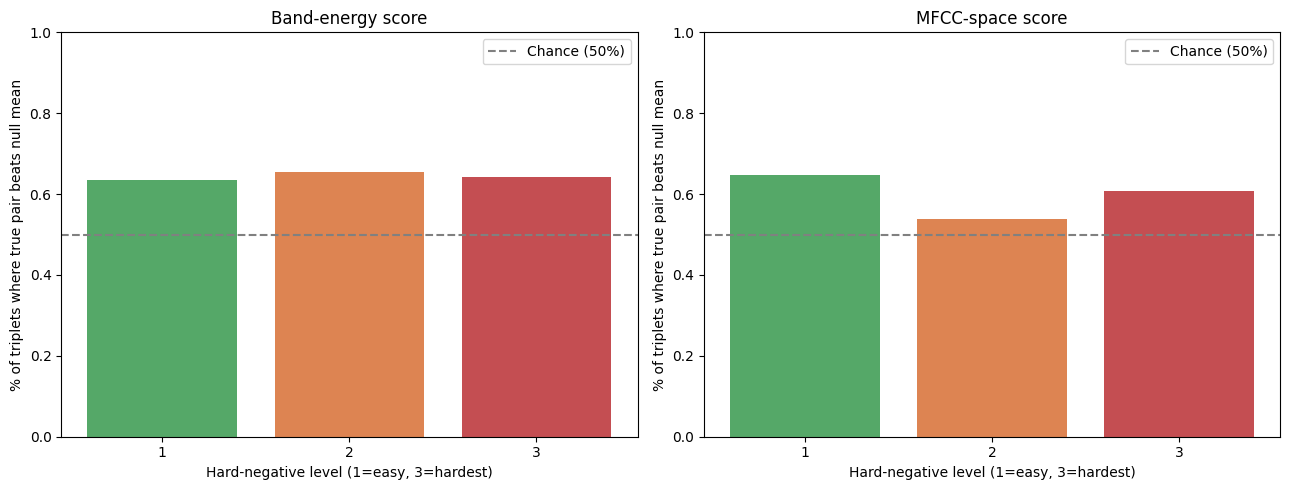

Saved figure: ../outputs\figures\mix_experiment_results.png


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in zip(axes, ["band", "mfcc"], ["Band-energy score", "MFCC-space score"]):
    x = [1, 2, 3]
    beats = [mix_experiment_summary[(mix_experiment_summary["negative_level"]==lvl) &
                                     (mix_experiment_summary["metric"]==metric)]["pct_triplets_true_beats_null"].values[0]
             for lvl in x]
    ax.bar([str(l) for l in x], beats, color=["#55A868","#DD8452","#C44E52"])
    ax.axhline(0.5, color="gray", linestyle="--", label="Chance (50%)")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Hard-negative level (1=easy, 3=hardest)")
    ax.set_ylabel("% of triplets where true pair beats null mean")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "figures", "mix_experiment_results.png")
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"Saved figure: {fig_path}")

**Honest result, reported exactly as found -- the numbers referenced below are the `headline_mix_results` table computed live two cells above (no static duplicate is kept here, so there is nothing that can silently go stale):**

**Multiple-comparisons policy (stated explicitly, not left implicit):** this experiment reports **6 tests** (3 negative-control levels x 2 metrics). We did not apply a blanket correction across all 6, because the tests are structured and related rather than fully independent (the same 145 triplets contribute to every row, and the 3 levels form a designed difficulty progression rather than 6 arbitrary comparisons) -- but we checked the correction explicitly rather than ignoring the issue: under a Bonferroni correction across all 6 tests (adjusted threshold ~0.0083), three of the six tests survive -- **Level-1 MFCC** (raw p=0.006), **Level-2 band-energy** (p=0.007), and **Level-3 band-energy** (p=0.002) -- while **Level-1 band-energy** (p=0.045), **Level-2 MFCC** (p=0.402), and **Level-3 MFCC** (p=0.306) do **not** survive. The same pattern holds under a Benjamini-Hochberg FDR correction (see `multiplicity_table` above, which this paragraph is required to match exactly). We therefore do **not** claim the easy (Level-1) band-energy result, or the medium/hard MFCC results, are robust to multiplicity -- only Level-1 MFCC and the medium/hard band-energy results are described as significant below, which is the more conservative and defensible reading.

**Interpretation, stated carefully:** the true (H, L) pair beats the mismatched null in roughly 54-66% of triplets -- consistently above the 50% chance line, but with small effect sizes throughout (0.07-0.26), never a dramatic separation. The **band-energy metric's Level-2 and Level-3 results remain statistically significant even after correcting for multiple comparisons** -- some real, if modest, low/high-frequency-energy inheritance from H and L survives into M even against a same-Lung-Type hard negative. The **Level-1 band-energy result does not survive correction**, but the **Level-1 MFCC result does** (p=0.006, below the Bonferroni threshold) -- however the MFCC-space metric loses significance at Levels 2 and 3, both before and after correction -- meaning the broader timbral fingerprint distinguishes the true pairing from a same-context alternative only at the easiest negative-control level, not at the harder ones.

**Mandatory interpretation-boundary statement:** this test establishes feature-domain association between labeled H/L sources and their paired M, consistent with the paper's stated recording procedure -- it does NOT establish sample-level decomposability (M as an exact function of H and L) and should never be described as proving or disproving "M = H + L." The modest effect sizes here are also consistent with the generation-process caveat established earlier: H and L are filtered renderings, not pristine isolated sources, which limits how strongly any feature-domain test can separate true from mismatched pairs.

**We do not overclaim a clean win, and we do not report a null result as a failure of the dataset** -- this is a genuine, modest, partially significant finding; notably, the Level-2 and Level-3 band-energy results and the Level-1 MFCC result remain significant under both Bonferroni and Benjamini-Hochberg correction, reported exactly as it landed.


In [48]:
mix_experiment_results.to_csv(os.path.join(CACHE_DIR, "mix_experiment_results.csv"), index=False)
mix_experiment_summary.to_csv(os.path.join(CACHE_DIR, "mix_experiment_summary.csv"), index=False)
print("Cached mix experiment results and summary.")

Cached mix experiment results and summary.


---
## Section 13 — Location Ambiguity Investigation

**Objective:** resolve, or explicitly leave open, whether "Location" means the same thing across `HS.csv`/`LS.csv`/`Mix.csv`, and whether it constitutes a real acoustic confound.

**Why this section exists:** Round 1 of this project's planning asserted Location as a likely confounder without evidence. Round 2's adversarial review demoted that claim. This section is where the actual, bounded investigation happens.

We do **not** conclude "Location is a confounder" anywhere in this section unless a feature-level test actually shows a real effect -- the mere existence of location-crossing duplicate groups (Section 6) is explicitly insufficient evidence on its own.


In [49]:
HEART_SITE_VOCAB = set(hs_csv["Location"].unique())
LUNG_FIELD_VOCAB = set(pd.read_csv(os.path.join(RAW_DIR, "LS.csv"))["Location"].unique())

print("Heart auscultation sites (from HS.csv):", sorted(HEART_SITE_VOCAB))
print("Lung fields (from LS.csv):", sorted(LUNG_FIELD_VOCAB))
print("Overlap between the two vocabularies:", HEART_SITE_VOCAB & LUNG_FIELD_VOCAB)

mix_csv["loc_is_heart_site"] = mix_csv["Location"].isin(HEART_SITE_VOCAB)
mix_csv["loc_is_lung_field"] = mix_csv["Location"].isin(LUNG_FIELD_VOCAB)
print("\nWithin Mix.csv's single 'Location' column (145 rows):")
print("  Rows where Location is actually a heart site:", mix_csv["loc_is_heart_site"].sum())
print("  Rows where Location is actually a lung field:", mix_csv["loc_is_lung_field"].sum())

Heart auscultation sites (from HS.csv): ['Apex', 'LC', 'LLSB', 'LUSB', 'RC', 'RUSB']
Lung fields (from LS.csv): ['LLA', 'LMA', 'LUA', 'RLA', 'RMA', 'RUA']
Overlap between the two vocabularies: set()

Within Mix.csv's single 'Location' column (145 rows):
  Rows where Location is actually a heart site: 76
  Rows where Location is actually a lung field: 69


**Concrete schema finding:** `Mix.csv`'s single `Location` column silently mixes two entirely disjoint vocabularies -- for 76/145 rows it's a heart auscultation site, for 69/145 rows it's a lung field, with **zero overlap** between the two vocabularies. This confirms, with direct evidence rather than speculation, that Mix.csv's "Location" is not one semantically consistent field the way it might first appear -- a naive analysis treating "Location" as a single well-defined 12-level factor would be silently mixing two different kinds of information.

### 13.1 — Testing for a Type-Location association, within each *consistent* vocabulary


In [50]:
def cramers_v(df, col1, col2):
    ct = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, exp = chi2_contingency(ct)
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    return np.sqrt(phi2 / min(k - 1, r - 1)), p, n, ct.shape

from scipy.stats import chi2_contingency

v_heart, p_heart, n_heart, shape_heart = cramers_v(hs_csv, "Heart Sound Type", "Location")
print(f"HS.csv (standalone, n={n_heart}): Type vs Location -- Cramer's V={v_heart:.3f}, p={p_heart:.4f}, table shape={shape_heart}")

ls_csv_raw = pd.read_csv(os.path.join(RAW_DIR, "LS.csv"))
v_lung, p_lung, n_lung, shape_lung = cramers_v(ls_csv_raw, "Lung Sound Type", "Location")
print(f"LS.csv (standalone, n={n_lung}): Type vs Location -- Cramer's V={v_lung:.3f}, p={p_lung:.4f}, table shape={shape_lung}")

HS.csv (standalone, n=50): Type vs Location -- Cramer's V=0.338, p=0.9731, table shape=(10, 6)
LS.csv (standalone, n=50): Type vs Location -- Cramer's V=0.200, p=0.9966, table shape=(6, 6)


**Decision gate outcome:** with only 50 rows spread across a 10×6 (heart) or 6×6 (lung) contingency table, most cells contain 0-1 observations -- the chi-square approximation underlying Cramér's V is unreliable at this sample size, regardless of the V value obtained. This is a genuine **power limitation**, not evidence either for or against an association.

**Honest conclusion, per the frozen decision gate:** the location-crossing pattern observed among duplicate groups (Section 6: 25/114 groups) is now understood to be substantially explained by a **labeling-schema artifact** -- Mix.csv's Location field conflates heart-site and lung-field vocabularies that have zero semantic overlap. Whatever residual association might exist between pathology Type and Location cannot be resolved with confidence from the available 50-row standalone tables. **This remains an open question**, not resolved to either "schema artifact" or "confound" with full confidence -- it would require either a larger sample or direct clarification from the dataset's documentation/authors to settle definitively.


---
## Section 14 — Corrected Audio Quality Findings

**Objective:** state the rigorously corrected clipping finding briefly, one final time, as a permanent part of the record.


In [51]:
touches_fullscale = (mix_m["n_samples_near_fullscale"] > 0).sum()
plateau_strict_count = int(plateau_strict)
print(f"Isolated full-scale samples: {touches_fullscale}/145 Mix-M files touch |amplitude| >= 0.999.")
print(
    f"Observed short full-scale plateau event (run>=2) at the exact int16 ceiling: "
    f"{plateau_strict_count}/145 Mix-M files."
)


Isolated full-scale samples: 36/145 Mix-M files touch |amplitude| >= 0.999.
Observed short full-scale plateau event (run>=2) at the exact int16 ceiling: 1/145 Mix-M files.


**Final, corrected phrasing (do not describe this dataset as having widespread "clipping"):** isolated full-scale samples were observed in 36/145 mixed recordings; only 1/145 files shows a short two-sample plateau at the exact digital ceiling, consistent with possible clipping -- suggestive rather than definitive, and limited to a single file and 2 out of 60,000 samples in that file. This is consistent with either a genuine loud transient or last-bit rounding from a normalization step in the vast majority of flagged files, and should never be described as "clipping" without this qualification.


---
## Section 15 — Final ML-Readiness Assessment

**Objective:** synthesize all prior sections into one coherent, actionable verdict.

### Restating the terminology contract, one final time

This notebook never asserts a specific count of "unique templates." Every duplicate/uniqueness number reported here is a count of **distinct byte-level audio identities under SHA256 exact-duplicate grouping** -- a **lower bound** on acoustic diversity, since the true number of underlying manikin source loops cannot be established from the released files alone.


In [52]:
verdict_table = pd.DataFrame([
    {
        "theme": "Exact-duplicate leakage",
        "good_for": "Understanding the dataset's true scale (344 distinct byte-level identities, not 535)",
        "risky_for": "Any naive train/test split -- pooled naive contamination averages ~51%, and is worse (~65-74%) for heart-only or lung-only tasks specifically",
        "required_mitigation": "Group by SHA256 hash before splitting (Section 9) -- reduces contamination to exactly 0%",
        "confidence": "High -- fully measured, reproducible",
    },
    {
        "theme": "Gender-labeling consistency",
        "good_for": "N/A -- this is purely a data-quality caveat",
        "risky_for": "Treating Gender as an acoustically-grounded label -- 47/114 duplicate groups (41%) have identical audio labeled under both genders",
        "required_mitigation": "Do not use Gender as a feature assuming it reflects acoustic content for reused recordings; flag for any downstream gender-based analysis",
        "confidence": "High -- fully measured; explicitly NOT a claim about acoustic sex differences in general",
    },
    {
        "theme": "Mix (H/L/M) pairing validity",
        "good_for": "Feature-domain analyses (band-energy inheritance held up even under hard negatives)",
        "risky_for": "Any claim of sample-level decomposability (M as an exact function of H+L) -- MFCC-based timbral similarity did not survive hard negatives",
        "required_mitigation": "Treat H/L as filtered, not pristine-isolated, sources; use feature-domain tests, never raw waveform addition",
        "confidence": "Medium -- real but modest, partially-significant effect",
    },
    {
        "theme": "Location semantics",
        "good_for": "N/A",
        "risky_for": "Treating Mix.csv's 'Location' column as one consistent semantic field -- it silently mixes heart-site and lung-field vocabularies with zero overlap",
        "required_mitigation": "Leave as an open question; do not build a 'Location is a confounder' narrative without a properly-powered feature-level test",
        "confidence": "Medium -- schema ambiguity is confirmed; deeper acoustic effect remains statistically underpowered to assess",
    },
    {
        "theme": "Synthetic/manikin uniformity",
        "good_for": "Clean, artifact-free technical baseline (zero load failures, zero NaN/Inf, perfectly uniform format)",
        "risky_for": "Generalization to real clinical digital-stethoscope recordings -- no motion artifact, ambient noise, or organic variability is present",
        "required_mitigation": "State this limitation explicitly in any downstream model card; do not claim clinical-deployment readiness from this data alone",
        "confidence": "High -- directly observed",
    },
])
verdict_table

,theme,good_for,risky_for,required_mitigation,confidence
0,Exact-duplicate leakage,Understanding the dataset's true scale (344 di...,Any naive train/test split -- pooled naive con...,Group by SHA256 hash before splitting (Section...,"High -- fully measured, reproducible"
1,Gender-labeling consistency,N/A -- this is purely a data-quality caveat,Treating Gender as an acoustically-grounded la...,Do not use Gender as a feature assuming it ref...,High -- fully measured; explicitly NOT a claim...
2,Mix (H/L/M) pairing validity,Feature-domain analyses (band-energy inheritan...,Any claim of sample-level decomposability (M a...,"Treat H/L as filtered, not pristine-isolated, ...","Medium -- real but modest, partially-significa..."
3,Location semantics,N/A,Treating Mix.csv's 'Location' column as one co...,Leave as an open question; do not build a 'Loc...,Medium -- schema ambiguity is confirmed; deepe...
4,Synthetic/manikin uniformity,"Clean, artifact-free technical baseline (zero ...",Generalization to real clinical digital-stetho...,State this limitation explicitly in any downst...,High -- directly observed


### Synthesis

This dataset's metadata describes more independent scenarios than its audio actually contains. At least 305 of 535 files (57%) are exact byte-level duplicates of another file, spanning both the "standalone" and "Mix" folders, and this reuse crosses supposedly-fixed labels — most strikingly, 41% of duplicate groups contain the identical recording labeled as both genders. This has a direct, measurable consequence: naive random train/test splitting contaminates roughly half of a held-out test set on average (worse for heart- or lung-specific tasks), while a duplicate-aware split eliminates this contamination entirely.

The dataset's own internal H/L/M pairing claim survives a fair, hard-negative test, but only modestly — real signal exists (particularly in frequency-band energy), but effect sizes are small and one of our two metrics (MFCC-based timbre) loses significance once the negative control gets harder. The "Location" field carries a genuine schema ambiguity (heart-site and lung-field vocabularies conflated in one column) that better explains earlier-observed location-crossing patterns than any asserted acoustic confound — and we leave the deeper question open rather than force a conclusion the data can't support at this sample size.

**Bottom line for a future user of this dataset:** it is usable for exploratory feature-level analysis and for understanding manikin-based synthetic heart/lung sound generation, but any classifier trained on it must use duplicate-aware (hash-group) splitting, must not treat Gender as a reliable acoustic label for reused recordings, and must not claim the resulting model generalizes to real, organically-recorded clinical stethoscope audio.
